In [2]:
import pandas as pd
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
path_statent = Path("../data/STATENT_2023.csv")
df_statent = pd.read_csv(path_statent, sep=";")  
df_statent.columns

Index(['ERHJAHR', 'PUBJAHR', 'E_KOORD', 'N_KOORD', 'RELI', 'B08T', 'B08S1',
       'B08S2', 'B08S3', 'B08EMPT',
       ...
       'B0894KB3', 'B0894KB4', 'B0895KB1', 'B0895KB2', 'B0895KB3', 'B0895KB4',
       'B0896KB1', 'B0896KB2', 'B0896KB3', 'B0896KB4'],
      dtype='str', length=652)

In [4]:
path_noloc = Path("../data/STATENT_NOLOC_2023.csv")
df_noloc = pd.read_csv(path_noloc, sep=";")  
df_noloc.columns

Index(['ERHJAHR', 'PUBJAHR', 'NOLOCSCE', 'E_KOORD', 'N_KOORD', 'RELI', 'B08T',
       'B08S1', 'B08S2', 'B08S3',
       ...
       'B0894KB3', 'B0894KB4', 'B0895KB1', 'B0895KB2', 'B0895KB3', 'B0895KB4',
       'B0896KB1', 'B0896KB2', 'B0896KB3', 'B0896KB4'],
      dtype='str', length=653)

In [5]:
path_gmde = Path("../data/STATENT_GMDE_2023.csv")
df_gmde = pd.read_csv(path_gmde, sep=";")  
df_gmde.columns

Index(['ERHJAHR', 'PUBJAHR', 'GDENR', 'GDE_HISTID', 'B08T', 'B08S1', 'B08S2',
       'B08S3', 'B08EMPT', 'B08EMPTS1',
       ...
       'B0894KB3', 'B0894KB4', 'B0895KB1', 'B0895KB2', 'B0895KB3', 'B0895KB4',
       'B0896KB1', 'B0896KB2', 'B0896KB3', 'B0896KB4'],
      dtype='str', length=651)

In [6]:

#Keep only commune ID, and total jobs (B08EMPT = total employment).
df_gmde = df_gmde[["GDENR", "GDE_HISTID", "B08EMPT"]].copy()
df_gmde = df_gmde.rename(columns={
    "GDENR": "commune_id",
    "GDE_HISTID": "commune_hist_id",
    "B08EMPT": "total_jobs"
})

In [7]:
cantons = gpd.read_file("../data/Boundaries_K4_Commune_20260101.gpkg")
print(cantons.columns, cantons.crs)
cantons.head()

Index(['GDENAME', 'GDEHISTID', 'GDENR', 'KTNAME', 'KTNR', 'KTKZ', 'geometry'], dtype='str') EPSG:2056


,GDENAME,GDEHISTID,GDENR,KTNAME,KTNR,KTKZ,geometry
0,Vionnaz,10078,6158,Valais / Wallis,23,VS,"POLYGON Z ((2559340 1129908 NaN, 2559838 11280..."
1,Speicher,10157,3023,Appenzell Ausserrhoden,15,AR,"POLYGON Z ((2750577 1255660 NaN, 2751887 12553..."
2,Zwischbergen,10159,6011,Valais / Wallis,23,VS,"POLYGON Z ((2649858 1121568 NaN, 2651538 11225..."
3,Villars-sur-Glâne,10162,2228,Fribourg / Freiburg,10,FR,"POLYGON Z ((2577605 1182163.001 NaN, 2577543 1..."
4,Villarsel-sur-Marly,10165,2230,Fribourg / Freiburg,10,FR,"POLYGON Z ((2578863 1179495.001 NaN, 2579945 1..."


In [8]:
df_cantons =  cantons[["GDENR", "GDEHISTID", "KTNR", "KTNAME"]].copy()
df_cantons = df_cantons.rename(columns={
    "GDENR": "commune_id",
    "GDEHISTID": "commune_hist_id",
    "KTNR": "canton_id",
    "KTNAME": "canton_name"
}).drop_duplicates()

In [9]:
df_merge = df_gmde.merge(
    df_cantons,
    on=["commune_id", "commune_hist_id"],
    how="left"
)
missing = df_merge[df_merge["canton_id"].isna()]
print("Unmatched communes:", missing.shape[0])
missing.to_csv("missing_communes.csv")

Unmatched communes: 49


In [10]:
jobs_commune = (
    df_merge
    .groupby(["commune_id", "commune_hist_id", "canton_id", "canton_name"], as_index=False)["total_jobs"]
    .sum()
    .rename(columns={"total_jobs": "total_jobs_commune"})
)

jobs_canton = (
    jobs_commune
    .groupby(["canton_id", "canton_name"], as_index=False)["total_jobs_commune"]
    .sum()
    .rename(columns={"total_jobs_commune": "total_jobs_cantons"})
)
print(jobs_canton)

    canton_id                       canton_name  total_jobs_cantons
0         1.0                            Zürich             1099035
1         2.0                      Bern / Berne              668654
2         3.0                            Luzern              266527
3         4.0                               Uri               19586
4         5.0                            Schwyz               92155
5         6.0                          Obwalden               23646
6         7.0                         Nidwalden               25421
7         8.0                            Glarus               23131
8         9.0                               Zug              131705
9        10.0               Fribourg / Freiburg              162628
10       11.0                         Solothurn              146705
11       12.0                       Basel-Stadt              199745
12       13.0                  Basel-Landschaft              160248
13       14.0                      Schaffhausen 

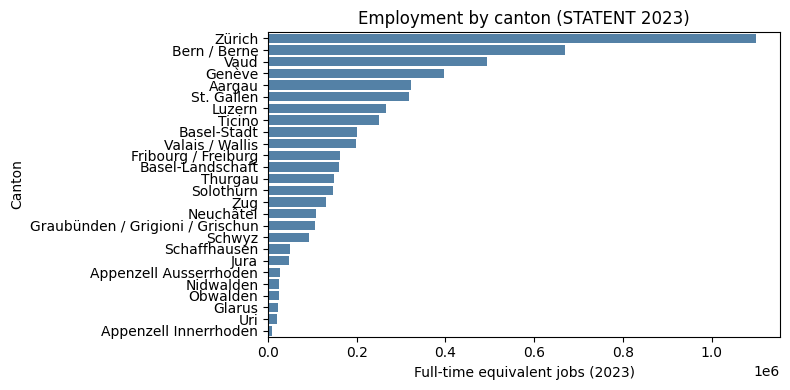

In [11]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=jobs_canton.sort_values("total_jobs_cantons", ascending=False),
    x="total_jobs_cantons",
    y="canton_name",
    color="steelblue"
)
plt.xlabel("Full-time equivalent jobs (2023)")
plt.ylabel("Canton")
plt.title("Employment by canton (STATENT 2023)")
plt.tight_layout()
plt.show()


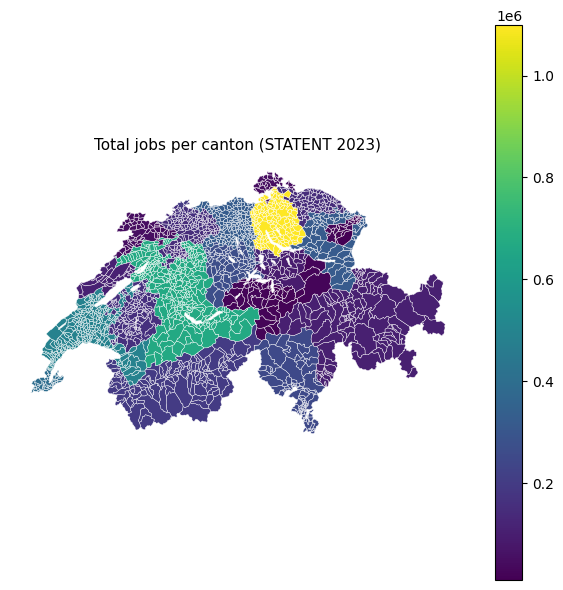

In [12]:
gdf_canton = cantons.merge(
    jobs_canton,
    left_on="KTNR",
    right_on="canton_id",
    how="left"
)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
gdf_canton.plot(
    column="total_jobs_cantons",
    cmap="viridis",
    linewidth=0.3,
    edgecolor="white",
    legend=True,
    ax=ax
)
ax.set_axis_off()
ax.set_title("Total jobs per canton (STATENT 2023)", fontsize=11)
plt.tight_layout()
plt.show()

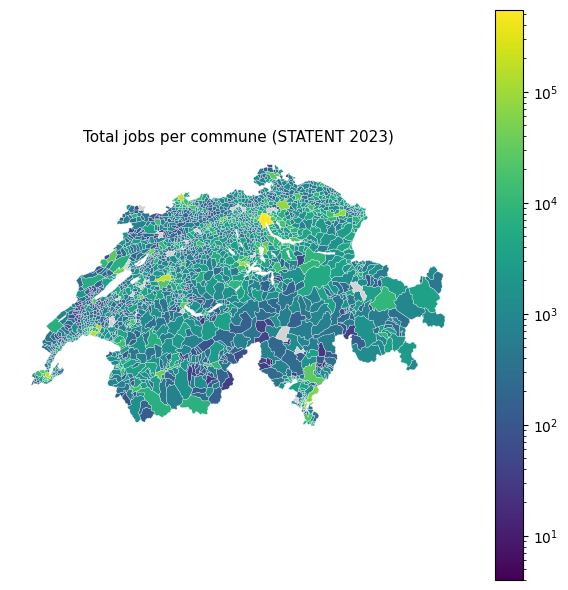

In [ ]:
from matplotlib.colors import LogNorm

gdf_commune = cantons.merge(
    jobs_commune,
    left_on="GDENR",
    right_on="commune_id",
    how="left"
)

# Log scale requires strictly positive values
gdf_commune["total_jobs_commune_log"] = gdf_commune["total_jobs_commune"].where(
    gdf_commune["total_jobs_commune"] > 0
)

vmin = gdf_commune["total_jobs_commune_log"].min()
vmax = gdf_commune["total_jobs_commune_log"].max()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
gdf_commune.plot(
    column="total_jobs_commune_log",
    cmap="viridis",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data / zero"}
)
ax.set_axis_off()
ax.set_title("Total jobs per commune (STATENT 2023)", fontsize=11)
plt.tight_layout()
plt.show()